# Partitionnement Hiérarchique Ascendant

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Quelques données simulées

Considérons quelques données pour étudier le comportement de diverses notions de dissimilarité entre groupes.

#### 1. Pour ce premier exercice, nous allons réutiliser les données du TD sur l'algorithme des k-moyennes. Utilisez `sklearn.cluster.AgglomerativeClustering` pour identifier des groupes dans ces données. Vous considérerez tour à tour les fonctions de dissimilarité entres groupes `single`, `complete`, et `average`.

#### 2. Visualisez le résultat obtenu. Quel méthode semble obtenir les meilleurs groupes ?

Considérez maintenant les données générées ci-après.

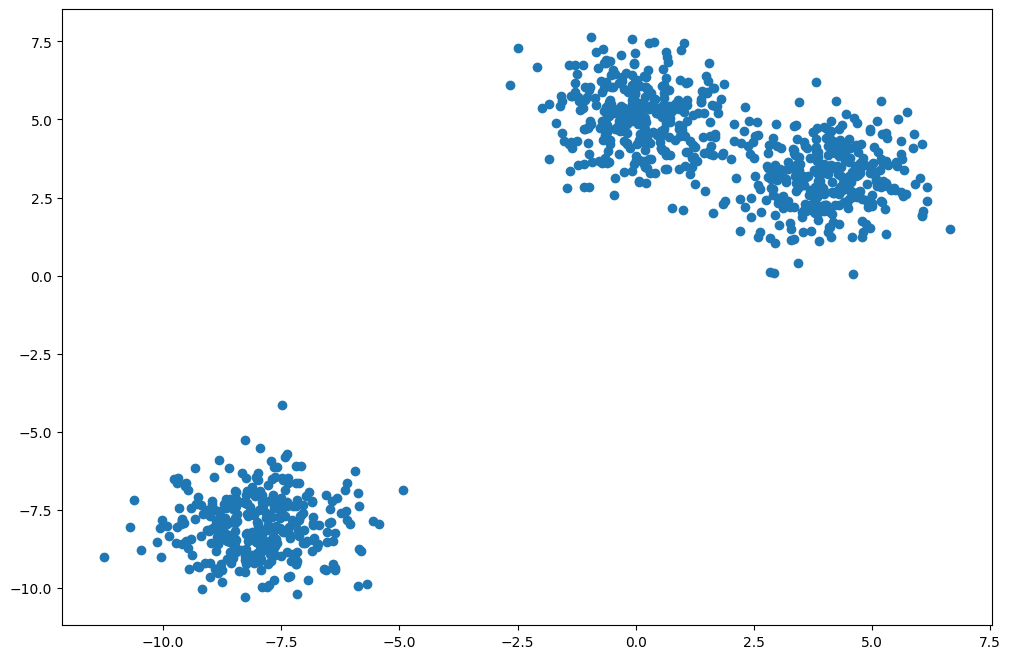

In [2]:
from sklearn.datasets import make_blobs
m = 1000
blobs_X,_ = make_blobs(m,centers=[[-8,-8],[0,5],[4,3]],random_state=42)
plt.scatter(blobs_X[:,0],blobs_X[:,1])

## Dataset MNIST

#### 3. Utilisez `sklearn.cluster.AgglomerativeClustering` pour identifier le nombre de groupes qui vous semble le plus adéquat dans ces nouvelles données. Vous considérerez tour à tour les fonctions de dissimilarité entres groupes `single`, `complete`,  `ward` et `average`. Visualisez le résultat. Que pouvez-vous en conclure ?

Nous allons maintenant nous intéresser au dataset MNIST.

In [1]:
mnist_X = pd.read_csv("../MNIST-20260105/mnist_data.csv")/100
mnist_y = pd.read_csv("../MNIST-20260105/mnist_labels.csv",dtype=int).squeeze()
plt.scatter(mnist_X["tSNE1"],mnist_X["tSNE2"],c=mnist_y)

NameError: name 'pd' is not defined

#### 4. Utilisez `sklearn.cluster.AgglomerativeClustering` pour identifier 10 groupes dans ces données. Vous considérerez tour à tour les fonctions de dissimilarité entres groupes `single`, `complete`, `ward` et `average`. 

#### 5. Visualisez les résultats. Que constatez vous ?

## Dendrogrammes

Lorsque le nombre de groupes à découvrir n'est pas spécifié (on initialise l'algorithme avec les paramètres `distance_threshold=0` et `n_clusters=None`). Il est possible d'afficher le dendrogramme qui donne l'ordre de formation des différents groupes.

#### 6. Inspirez-vous du code fournit sur la page `https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html` pour afficher le dendrogramme obtenu sur les données MNIST par l'approche par `average linkage`.

## Données députés

Nous allons maintenant travailler sur les données députés.

In [4]:
deputes = pd.read_csv('deputes.csv',delimiter=';')
deputes

,id,nom,nom_de_famille,prenom,sexe,date_naissance,lieu_naissance,num_deptmt,nom_circo,num_circo,...,hemicycle_interventions,hemicycle_interventions_courtes,amendements_proposes,amendements_signes,amendements_adoptes,rapports,propositions_ecrites,propositions_signees,questions_ecrites,questions_orales
0,32,Damien Abad,Abad,Damien,H,1980-04-05,Nîmes (Gard),01,Ain,5,...,160,219,4,1315,42,0,4,68,52,8
1,43,Caroline Abadie,Abadie,Caroline,F,1976-09-07,Saint-Martin-d'Hères (Isère),38,Isère,8,...,15,7,22,403,237,0,0,10,2,1
2,493,Jean-Félix Acquaviva,Acquaviva,Jean-Félix,H,1973-03-19,Bastia (Haute-Corse),2B,Haute-Corse,2,...,120,7,189,2215,68,0,0,11,20,4
3,152,Lénaïck Adam,Adam,Lénaïck,H,1992-02-19,Saint Laurent du Maroni (Guyane),973,Guyane,2,...,6,1,44,606,261,1,2,14,2,0
4,234,Damien Adam,Adam,Damien,H,1989-06-28,Orléans (Loiret),76,Seine-Maritime,1,...,17,5,102,626,276,1,1,19,13,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,215,Hubert Wulfranc,Wulfranc,Hubert,H,1956-12-17,Rouen (Seine-Maritime),76,Seine-Maritime,3,...,124,51,61,1830,76,0,3,40,33,14
535,130,Hélène Zannier,Zannier,Hélène,F,1972-09-19,Saint-Avold (Moselle),57,Moselle,7,...,8,1,10,559,275,0,0,18,21,1
536,614,Souad Zitouni,Zitouni,Souad,F,1974-04-23,Boukadir (Algérie),84,Vaucluse,1,...,23,8,114,951,274,0,0,18,4,1
537,31,Jean-Marc Zulesi,Zulesi,Jean-Marc,H,1988-06-06,Marseille (Bouches-du-Rhône),13,Bouches-du-Rhône,8,...,21,12,128,1045,351,2,0,19,42,2


In [5]:
deputes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               539 non-null    int64  
 1   nom                              539 non-null    object 
 2   nom_de_famille                   539 non-null    object 
 3   prenom                           539 non-null    object 
 4   sexe                             539 non-null    object 
 5   date_naissance                   539 non-null    object 
 6   lieu_naissance                   539 non-null    object 
 7   num_deptmt                       539 non-null    object 
 8   nom_circo                        539 non-null    object 
 9   num_circo                        539 non-null    int64  
 10  mandat_debut                     539 non-null    object 
 11  mandat_fin                       0 non-null      float64
 12  ancien_depute         

In [6]:
dim_activite = ["semaines_presence","commission_presences","commission_interventions","hemicycle_interventions","hemicycle_interventions_courtes","amendements_proposes","amendements_signes","amendements_adoptes","rapports","propositions_ecrites","propositions_signees","questions_ecrites","questions_orales"]

#### 7. Sélectionnez les données qui correspondent aux activités des députés dans l'hémicycle, c'est à dire les colonnes indiquées dans la variable `dim_activite`.  Vous pouvez ajouter d'autres colonnes si cela vous semble pertinent.

#### 8. Utilisez la méthode de prétraitement `sklearn.preprocessing.StandardScaler` avec les paramètres par défaut pour normaliser les données. Que fait cette fonction de prétraitement ?

#### 9. Utiliser la dissimilarité  `ward linkage` qui a pour objectif, comme les k-moyennes, de minimiser la variance intra classe des différents groupes. Affichez le dendrogramme que l'on obtient sur les données des députés lorsque l'on effectue un partitionnement hiérarchique avec cette méthode. Combien de groupes le dendrogramme suggère-t-il de sélectionner ?

#### 10. Apprenez un nouveau modèle pour séparer les données en 2 groupes.

Le code suivant permet d'afficher la matrice de contingence entre la colonne `parti_ratt_financier` et la colonne `groupe_sigle` des données députés.

In [7]:
from sklearn.metrics.cluster import contingency_matrix
deputes_sigle,deputes_sigle_inv = np.unique(deputes["groupe_sigle"],return_inverse=True)
deputes_finance,deputes_finance_inv = np.unique(deputes["parti_ratt_financier"],return_inverse=True)
pd.DataFrame(contingency_matrix(deputes_sigle_inv,deputes_finance_inv),columns=deputes_finance,index=deputes_sigle)

,Calédonie Ensemble,Cap sur l'avenir,Debout la France,Europe Écologie Les Verts,La France Insoumise,La République en Marche,Les Républicains,Mouvement Démocrate,Non déclaré(s),Non rattachée,Parti communiste français,Parti progressiste martiniquais,Parti radical de gauche,Parti socialiste,Rassemblement national,Régions et peuples solidaires,Tapura Huiraatira,Tavini Huiraatira No Te Ao Maohi - Front de libération de Polynésie,"Union des démocrates, radicaux et libéraux"
AE,0,0,0,0,0,5,0,12,0,1,0,0,0,0,0,0,1,0,1
GDR,0,0,0,0,0,0,0,0,0,0,14,0,0,0,0,0,0,1,0
LFI,0,0,0,0,17,0,0,0,0,0,0,0,0,0,0,0,0,0,0
LR,0,0,0,0,0,0,90,0,0,0,0,0,0,0,0,0,0,0,1
LREM,0,1,0,0,0,258,0,0,0,0,0,0,0,0,0,0,0,0,1
LT,0,0,0,1,0,0,0,0,0,0,0,0,3,0,0,10,0,0,4
MODEM,0,0,0,0,0,0,0,52,0,0,0,0,0,0,0,1,0,0,2
NI,0,0,3,11,0,0,0,0,2,0,0,0,0,0,6,0,0,0,0
SOC,0,0,0,1,0,0,0,0,0,0,0,3,0,21,0,0,0,0,0
UDI,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,13


On y apprend par exemple que certains membres du groupe `LREM` à l'assemblée sont financés par des partis autres que `La République en Marche`. De la même façon, un des députés financé par `Les Républicains` fait parti du groupe `UDI` à l'assemblée.

#### 11. Utilisez la même approche pour étudier les liens entre les 2 groupes que vous avez obtenus et les `groupe_sigle` à l'assemblée. Que constatez-vous ?